**ASH - DATA LOADING AND EXPLORING**

**Data Loading & Initial Exploration**

In [ ]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # useful for visualizations

# Load dataset
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

# Check shape (rows, columns)
print("Shape of dataset:", df.shape)

# View first 5 rows
df.head()

# Check data types
df.dtypes

Shape of dataset: (253680, 22)


,0
Diabetes_binary,float64
HighBP,float64
HighChol,float64
CholCheck,float64
BMI,float64
Smoker,float64
Stroke,float64
HeartDiseaseorAttack,float64
PhysActivity,float64
Fruits,float64


**Descriptive Statistics & Data Quality Checks**

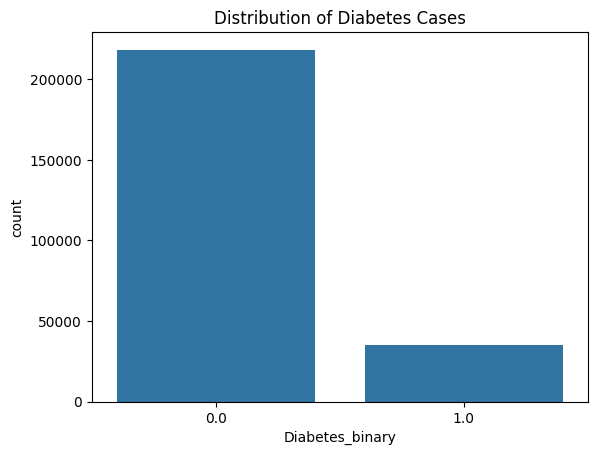

,proportion
Diabetes_binary,
0.0,0.860667
1.0,0.139333


In [ ]:
import seaborn as sns

sns.countplot(x='Diabetes_binary', data=df)
plt.title('Distribution of Diabetes Cases')
plt.show()
# Descriptive statistics
df.describe()

# Check for missing values
df.isnull().sum()

# Check for duplicate rows
df.duplicated().sum()

# Distribution of target variable (Diabetes)
df['Diabetes_binary'].value_counts(normalize=True)

**Data Visualizations**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

**CHART 1 – Class Balance (Diabetes vs No Diabetes)**

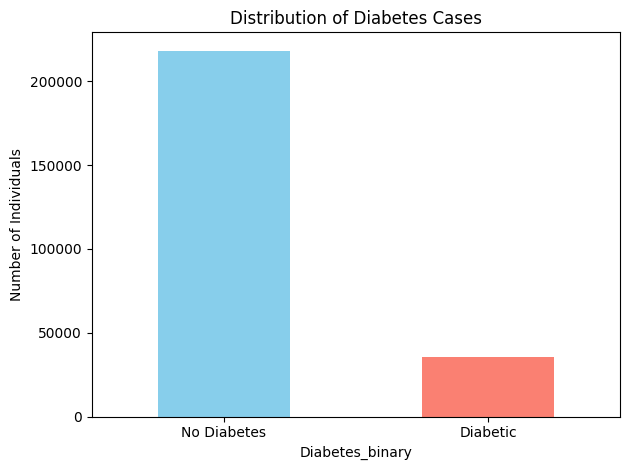

In [ ]:
df['Diabetes_binary'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])

plt.title('Distribution of Diabetes Cases')
plt.xticks([0, 1], ['No Diabetes', 'Diabetic'], rotation=0)
plt.ylabel('Number of Individuals')

plt.tight_layout()
plt.savefig('class_balance.png')
plt.show()

**CHART 2 – BMI Distribution by Diabetes Status**

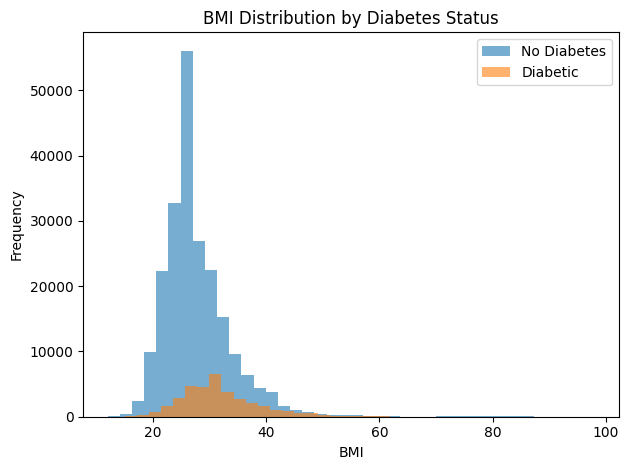

In [ ]:
df[df['Diabetes_binary'] == 0]['BMI'].plot(
    kind='hist', alpha=0.6, bins=40, label='No Diabetes'
)

df[df['Diabetes_binary'] == 1]['BMI'].plot(
    kind='hist', alpha=0.6, bins=40, label='Diabetic'
)

plt.title('BMI Distribution by Diabetes Status')
plt.xlabel('BMI')
plt.legend()

plt.tight_layout()
plt.savefig('bmi_distribution.png')
plt.show()

**Chart 3 – Diabetes Rate by Income Level**

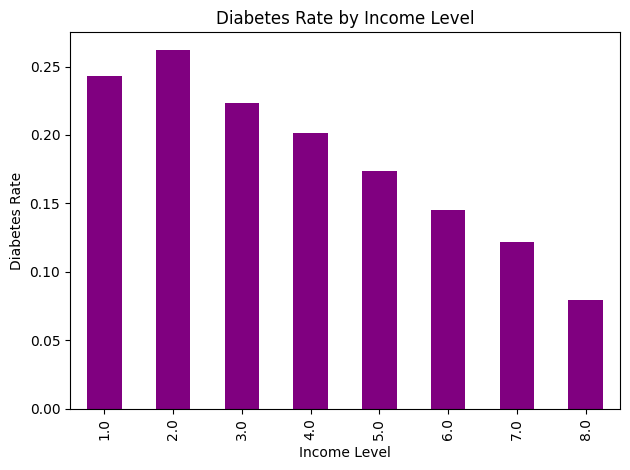

In [ ]:
df.groupby('Income')['Diabetes_binary'].mean().plot(kind='bar', color='purple')

plt.title('Diabetes Rate by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Diabetes Rate')

plt.tight_layout()
plt.savefig('diabetes_by_income.png')
plt.show()

**Chart 4 – Correlation Heatmap**

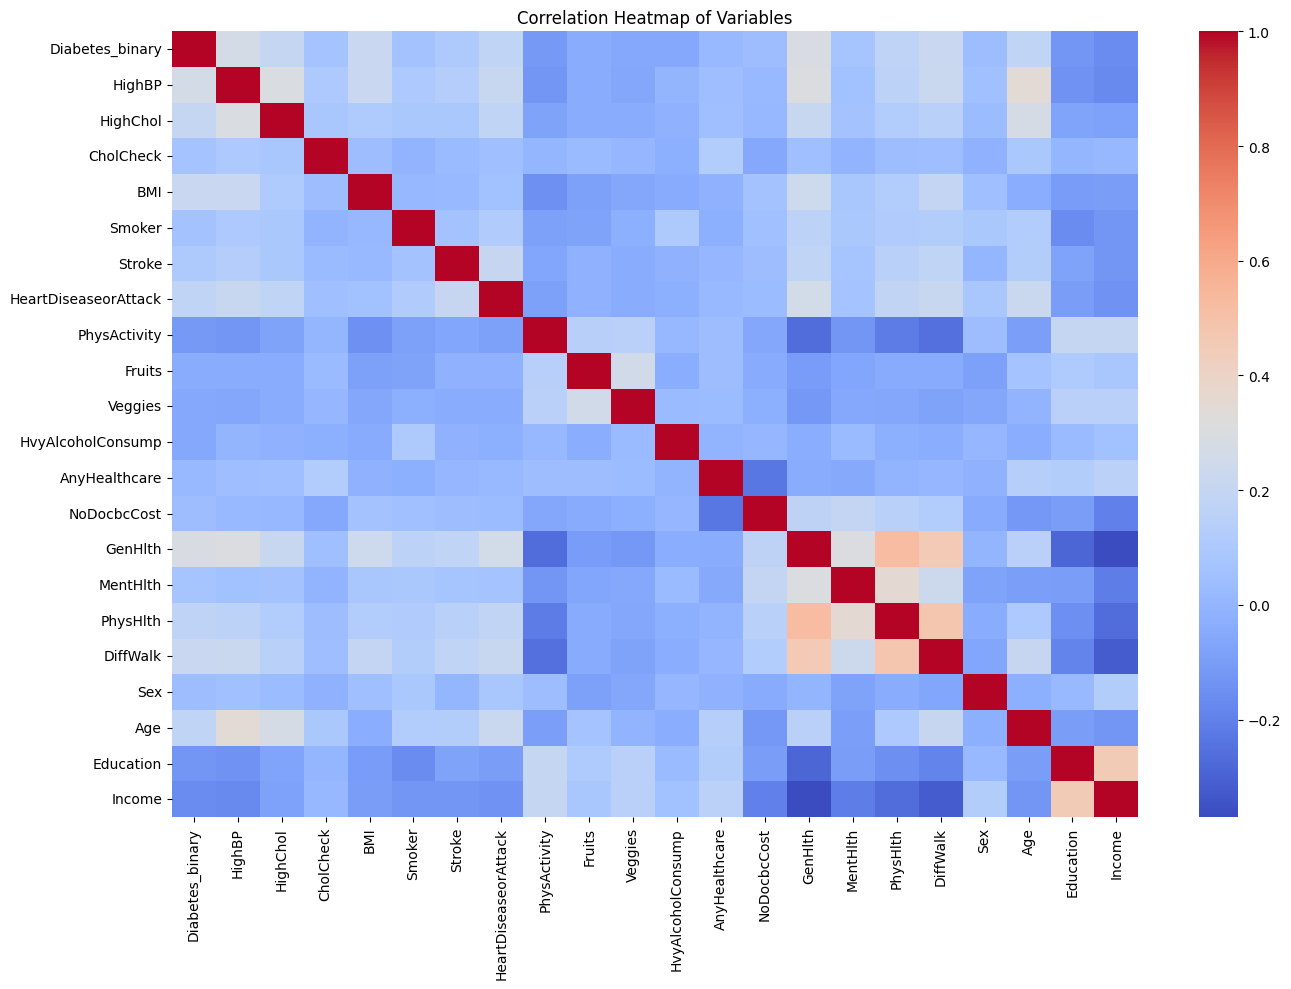

In [ ]:
plt.figure(figsize=(14, 10))

corr = df.corr()

sns.heatmap(corr, cmap='coolwarm', annot=False)

plt.title('Correlation Heatmap of Variables')

plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

**GARRISON - DATA CLEANING AND PREPROCESSING**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Initial Data Overview

In [ ]:
df_clean = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")

In [ ]:
print("--- Basic Info ---")
df_clean.info()
print("\n--- Shape ---")
print(df_clean.shape)
print("\n--- Missing Values ---")
print(df_clean.isnull().sum().sum(), "total missing values")
print("\n--- Duplicates ---")
print(df_clean.duplicated().sum(), "duplicate rows found")
print("\n--- Target Distribution (Diabetes_binary) ---")
print(df_clean['Diabetes_binary'].value_counts(normalize=True) * 100)

--- Basic Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93579 entries, 0 to 93578
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       93579 non-null  float64
 1   HighBP                93579 non-null  float64
 2   HighChol              93579 non-null  float64
 3   CholCheck             93579 non-null  float64
 4   BMI                   93579 non-null  float64
 5   Smoker                93579 non-null  float64
 6   Stroke                93579 non-null  float64
 7   HeartDiseaseorAttack  93579 non-null  float64
 8   PhysActivity          93579 non-null  float64
 9   Fruits                93579 non-null  float64
 10  Veggies               93579 non-null  float64
 11  HvyAlcoholConsump     93579 non-null  float64
 12  AnyHealthcare         93579 non-null  float64
 13  NoDocbcCost           93579 non-null  float64
 14  GenHlth               93579 non-null  float64
 15  

Handle Duplicates & Check Data Quality

In [ ]:
initial_rows = len(df_clean)

# Remove duplicates
df_clean = df_clean.drop_duplicates()
removed_dupes = initial_rows - len(df_clean)

# Check for invalid values
invalid_bmi = (df_clean['BMI'] <= 0).sum()
invalid_physhlth = (df_clean['PhysHlth'] > 30).sum() | (df_clean['PhysHlth'] < 0).sum()
invalid_menthlth = (df_clean['MentHlth'] > 30).sum() | (df_clean['MentHlth'] < 0).sum()

print(f"Removed {removed_dupes} duplicate rows.")
print(f"Current shape: {df_clean.shape}")
print(f"Invalid BMI values (<=0): {invalid_bmi}")
print(f"Invalid PhysHlth values (>30 or <0): {invalid_physhlth}")
print(f"Invalid MentHlth values (>30 or <0): {invalid_menthlth}")

Removed 5416 duplicate rows.
Current shape: (88163, 22)
Invalid BMI values (<=0): 0
Invalid PhysHlth values (>30 or <0): 0
Invalid MentHlth values (>30 or <0): 0


Handle Outliers

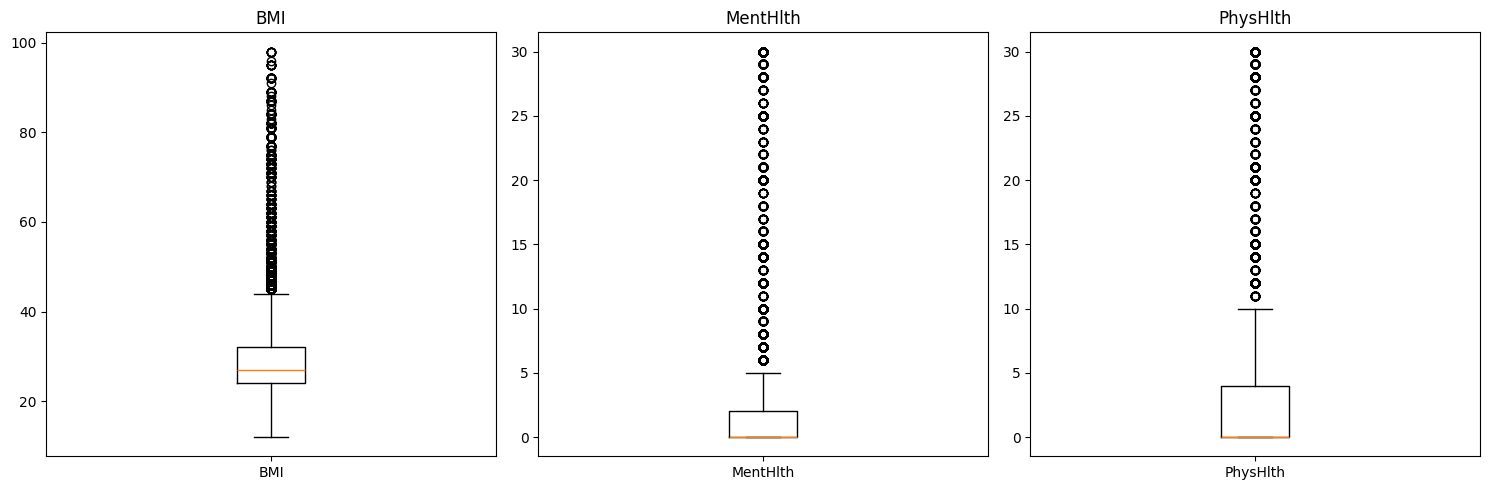

Number of BMI outliers (using 1.5*IQR): 2394 (2.72%)
Note: Outliers are kept as they represent real health conditions relevant to diabetes.


In [ ]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.boxplot(df_clean['BMI'], tick_labels=['BMI'])
plt.title('BMI')

plt.subplot(1, 3, 2)
plt.boxplot(df_clean['MentHlth'], tick_labels=['MentHlth'])
plt.title('MentHlth')

plt.subplot(1, 3, 3)
plt.boxplot(df_clean['PhysHlth'], tick_labels=['PhysHlth'])
plt.title('PhysHlth')
plt.tight_layout()
plt.show()

# BMI Outlier Stats (using IQR)
Q1 = df_clean['BMI'].quantile(0.25)
Q3 = df_clean['BMI'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

bmi_outliers = ((df_clean['BMI'] < lower_bound) | (df_clean['BMI'] > upper_bound)).sum()
print(f"Number of BMI outliers (using 1.5*IQR): {bmi_outliers} ({bmi_outliers/len(df_clean)*100:.2f}%)")
print("Note: Outliers are kept as they represent real health conditions relevant to diabetes.")

Feature Engineering

In [ ]:
# 1. BMI Categories (Underweight: <18.5, Normal: 18.5-24.9, Overweight: 25-29.9, Obese: >=30)
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Normal'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df_clean['BMI_Category'] = df_clean['BMI'].apply(categorize_bmi)

# 2. Interaction Feature: HighBP & HighChol combined
# 1 if both are 1, 0 otherwise
df_clean['HighBP_HighChol'] = ((df_clean['HighBP'] == 1) & (df_clean['HighChol'] == 1)).astype(int)

print("New features created: 'BMI_Category' and 'HighBP_HighChol'")
display(df_clean[['BMI', 'BMI_Category', 'HighBP', 'HighChol', 'HighBP_HighChol']].head())

New features created: 'BMI_Category' and 'HighBP_HighChol'


,BMI,BMI_Category,HighBP,HighChol,HighBP_HighChol
0,40.0,Obese,1.0,1.0,1
1,25.0,Overweight,0.0,0.0,0
2,28.0,Overweight,1.0,1.0,1
3,27.0,Overweight,1.0,0.0,0
4,24.0,Normal,1.0,1.0,1


Prepare Features & Target

In [ ]:
# Need to one-hot encode the new categorical BMI column before splitting
df_clean = pd.get_dummies(df_clean, columns=['BMI_Category'], drop_first=True)

X = df_clean.drop('Diabetes_binary', axis=1)
y = df_clean['Diabetes_binary']

# Identifying feature types
binary_features = [col for col in X.columns if X[col].nunique() == 2]
continuous_features = ['BMI', 'MentHlth', 'PhysHlth']
ordinal_features = ['Age', 'Education', 'Income', 'GenHlth']

print(f"Target variable: 'Diabetes_binary'")
print(f"Total features in X: {X.shape[1]}")
print(f"Binary Features ({len(binary_features)}): {binary_features}")
print(f"Continuous Features ({len(continuous_features)}): {continuous_features}")
print(f"Ordinal Features ({len(ordinal_features)}): {ordinal_features}")

Target variable: 'Diabetes_binary'
Total features in X: 25
Binary Features (18): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'HighBP_HighChol', 'BMI_Category_Obese', 'BMI_Category_Overweight', 'BMI_Category_Underweight']
Continuous Features (3): ['BMI', 'MentHlth', 'PhysHlth']
Ordinal Features (4): ['Age', 'Education', 'Income', 'GenHlth']


Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set shape: X={X_test.shape}, y={y_test.shape}")
print("\nClass distribution in Train (%):\n", y_train.value_counts(normalize=True) * 100)
print("\nClass distribution in Test (%):\n", y_test.value_counts(normalize=True) * 100)

Training set shape: X=(70530, 25), y=(70530,)
Testing set shape: X=(17633, 25), y=(17633,)

Class distribution in Train (%):
 Diabetes_binary
0.0    85.258755
1.0    14.741245
Name: proportion, dtype: float64

Class distribution in Test (%):
 Diabetes_binary
0.0    85.260591
1.0    14.739409
Name: proportion, dtype: float64


Scale Features

In [ ]:
scaler = StandardScaler()

# Fit on training data only, transform both
X_train[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test[continuous_features] = scaler.transform(X_test[continuous_features])

print(f"Scaled features: {continuous_features}")
print("\nVerification (Train BMI mean/std):")
print(f"Mean: {X_train['BMI'].mean():.4f}, Std: {X_train['BMI'].std():.4f}")

Scaled features: ['BMI', 'MentHlth', 'PhysHlth']

Verification (Train BMI mean/std):
Mean: -0.0000, Std: 1.0000


Save Cleaned Dataset

In [ ]:
# Combine X and y back together for the final cleaned file (using the unscaled, cleaned dataframe)
final_cleaned_df = pd.concat([y, X], axis=1)

filename = "diabetes_cleaned.csv"
final_cleaned_df.to_csv(filename, index=False)
print(f"Successfully saved cleaned dataset as: {filename}")

Successfully saved cleaned dataset as: diabetes_cleaned.csv


In [ ]:
print("=== Before / After Summary ===")
print(f"Original Shape: {df_clean.shape}")
print(f"Cleaned Shape: {final_cleaned_df.shape}")
print(f"\nRows removed (Duplicates): {len(df_clean) - len(final_cleaned_df)}")
print(f"New Features Added: 'HighBP_HighChol', plus OHE BMI Categories")

print("\nSummary of Improvements:")
print("- Duplicates removed")
print("- Engineered interaction term for HighBP & HighChol")
print("- Converted continuous BMI into categorical OHE features")
print("- Data is now split and scaled, ready for modeling")

=== Before / After Summary ===
Original Shape: (229474, 26)
Cleaned Shape: (229474, 26)

Rows removed (Duplicates): 0
New Features Added: 'HighBP_HighChol', plus OHE BMI Categories

Summary of Improvements:
- Duplicates removed
- Engineered interaction term for HighBP & HighChol
- Converted continuous BMI into categorical OHE features
- Data is now split and scaled, ready for modeling


**BRIANNA - 3 MODELS + CONFUSION MATRICES**

Import Libraries

In [ ]:
#Data Handling and Persistence
import pickle, numpy

In [ ]:
# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,
                             ConfusionMatrixDisplay)

# Visualization
import matplotlib.pyplot

Model 1 - Logistic Regression

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

         0.0       0.94      0.71      0.81     38876
         1.0       0.32      0.76      0.45      7019

    accuracy                           0.71     45895
   macro avg       0.63      0.73      0.63     45895
weighted avg       0.85      0.71      0.75     45895

ROC AUC Score: 0.8120


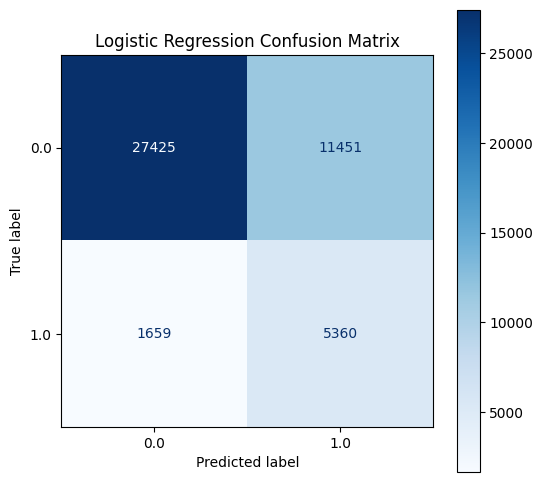

In [ ]:
# Model Initialization
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Training and Prediction
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:,1]

# Performance Metrics
print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_lr))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")

# Visualization and Saving
fig, ax = matplotlib.pyplot.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Blues', ax=ax)
ax.set_title("Logistic Regression Confusion Matrix")
matplotlib.pyplot.savefig('logistic_regression_confusion_matrix.png')
matplotlib.pyplot.show()

Model 2 - Random Forest

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91     38876
         1.0       0.46      0.15      0.23      7019

    accuracy                           0.84     45895
   macro avg       0.66      0.56      0.57     45895
weighted avg       0.80      0.84      0.81     45895

ROC AUC Score: 0.7757


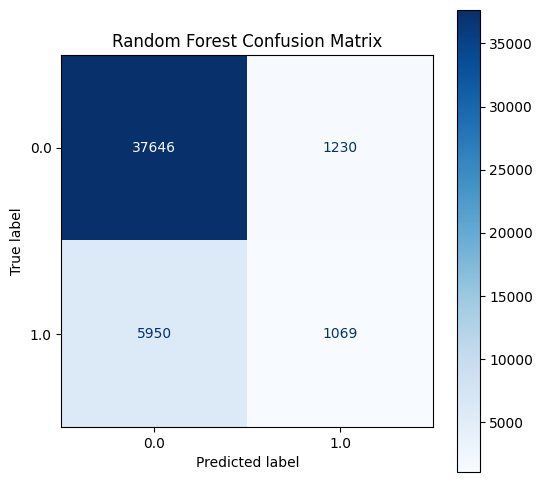

In [ ]:
# Model Initialization
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1)

# Training and Prediction
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:,1]

# Performance Metrics
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

# Visualization and Saving
fig, ax = matplotlib.pyplot.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Blues', ax=ax)
ax.set_title("Random Forest Confusion Matrix")
matplotlib.pyplot.savefig('random_forest_confusion_matrix.png')
matplotlib.pyplot.show()

Model 3 - Decision Tree

Income
1.0    0.243387
2.0    0.262504
3.0    0.223869
4.0    0.202827
5.0    0.177249
6.0    0.150471
7.0    0.130224
8.0    0.098297
Name: Diabetes_binary, dtype: float64

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

         0.0       0.94      0.67      0.78     38876
         1.0       0.30      0.78      0.43      7019

    accuracy                           0.68     45895
   macro avg       0.62      0.73      0.61     45895
weighted avg       0.85      0.68      0.73     45895

ROC AUC Score: 0.7993


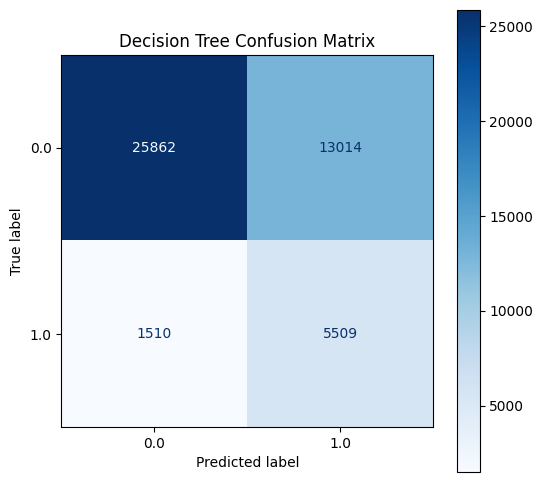

In [ ]:
# Exploratory Analysis
print(df_clean.groupby('Income')['Diabetes_binary'].mean())

# Model Initialization
dt_model = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)

# Training and Predictions
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:,1]

# Performance Metrics
print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred_dt))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_dt):.4f}")

# Visualization
fig, ax = matplotlib.pyplot.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, cmap='Blues', ax=ax)
ax.set_title("Decision Tree Confusion Matrix")
matplotlib.pyplot.savefig('decision_tree_confusion_matrix.png')
matplotlib.pyplot.show()

Correlation Heatmap

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, f1_score

# Summary Results
results = pd.DataFrame({
    'Model':              ['Logistic Regression', 'Random Forest', 'Decision Tree'],
    'Accuracy':           [round(accuracy_score(y_test, y_pred_lr), 4),
                           round(accuracy_score(y_test, y_pred_rf), 4),
                           round(accuracy_score(y_test, y_pred_dt), 4)],
    'AUC-ROC':            [round(roc_auc_score(y_test, y_proba_lr), 4),
                           round(roc_auc_score(y_test, y_proba_rf), 4),
                           round(roc_auc_score(y_test, y_proba_dt), 4)],
    'Recall (Diabetic)':  [round(recall_score(y_test, y_pred_lr), 4),
                           round(recall_score(y_test, y_pred_rf), 4),
                           round(recall_score(y_test, y_pred_dt), 4)],
    'F1-Score':           [round(f1_score(y_test, y_pred_lr), 4),
                           round(f1_score(y_test, y_pred_rf), 4),
                           round(f1_score(y_test, y_pred_dt), 4)]
})

print("=== MODEL COMPARISON ===")
print(results.to_string(index=False))


=== MODEL COMPARISON ===
              Model  Accuracy  AUC-ROC  Recall (Diabetic)  F1-Score
Logistic Regression    0.7143   0.8120             0.7636    0.4499
      Random Forest    0.8436   0.7757             0.1523    0.2294
      Decision Tree    0.6835   0.7993             0.7849    0.4314


**HAYLEY - FEATURE IMPORTANCE AND INSIGHTS**

In [ ]:
#Load data and retrain Random Forest
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, f1_score, RocCurveDisplay

print("Data (X_train, X_test, y_train, y_test) is already loaded in memory.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


Data (X_train, X_test, y_train, y_test) is already loaded in memory.
X_train shape: (183579, 25)
X_test shape: (45895, 25)


In [ ]:
# Retrain Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Random Forest retrained successfully.")

Random Forest retrained successfully.


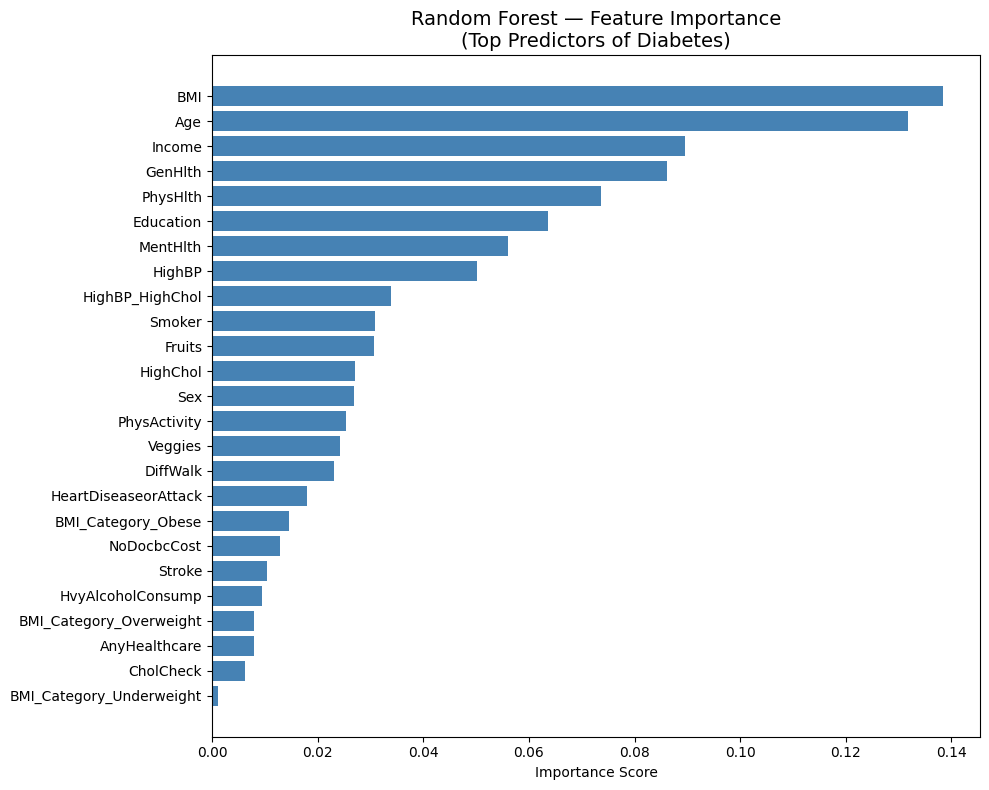


Top 5 Predictors of Diabetes:
 Feature  Importance
PhysHlth    0.073610
 GenHlth    0.086090
  Income    0.089575
     Age    0.131725
     BMI    0.138486


In [ ]:
#Feature Importance Chart
feature_names = X_train.columns
importances = rf_model.feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title('Random Forest — Feature Importance\n(Top Predictors of Diabetes)', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print("\nTop 5 Predictors of Diabetes:")
print(feat_df.tail(5)[['Feature', 'Importance']].to_string(index=False))

In [ ]:
#Model Comparison Table

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:,1]

dt_model = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:,1]

rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:,1]

results = pd.DataFrame({
    'Model':              ['Logistic Regression', 'Random Forest', 'Decision Tree'],
    'Accuracy':           [round(accuracy_score(y_test, lr_preds), 4),
                           round(accuracy_score(y_test, rf_preds), 4),
                           round(accuracy_score(y_test, dt_preds), 4)],
    'AUC-ROC':            [round(roc_auc_score(y_test, lr_proba), 4),
                           round(roc_auc_score(y_test, rf_proba), 4),
                           round(roc_auc_score(y_test, dt_proba), 4)],
    'Recall (Diabetic)':  [round(recall_score(y_test, lr_preds), 4),
                           round(recall_score(y_test, rf_preds), 4),
                           round(recall_score(y_test, dt_preds), 4)],
    'F1-Score':           [round(f1_score(y_test, lr_preds), 4),
                           round(f1_score(y_test, rf_preds), 4),
                           round(f1_score(y_test, dt_preds), 4)]
})

print("=== MODEL COMPARISON ===")
print(results.to_string(index=False))

=== MODEL COMPARISON ===
              Model  Accuracy  AUC-ROC  Recall (Diabetic)  F1-Score
Logistic Regression    0.7143   0.8120             0.7636    0.4499
      Random Forest    0.8436   0.7757             0.1523    0.2294
      Decision Tree    0.6835   0.7993             0.7849    0.4314


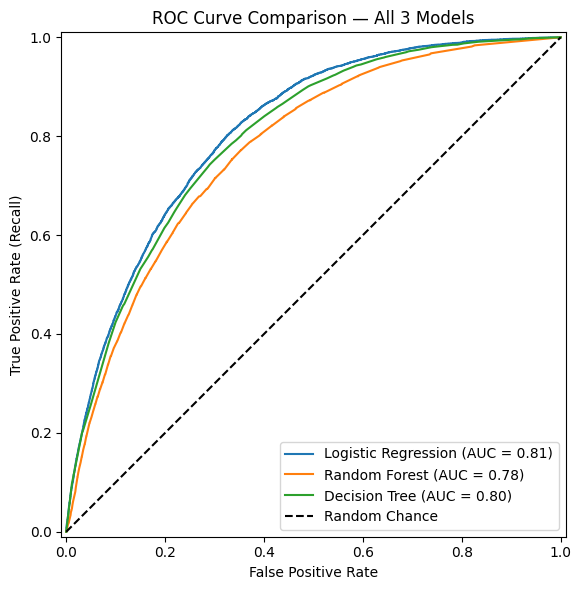

In [ ]:
# ROC Curve — All 3 Models on One Chart
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, lr_proba, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_proba, name='Random Forest', ax=ax)
RocCurveDisplay.from_predictions(y_test, dt_proba, name='Decision Tree', ax=ax)

ax.plot([0,1], [0,1], 'k--', label='Random Chance')
ax.set_title('ROC Curve Comparison — All 3 Models')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_comparison.png') # Changed path to local directory
plt.show()

In [ ]:
#Managerial Insights Summary

print("""
=== MANAGERIAL INSIGHTS ===

1. TOP PREDICTORS
   The most important features for predicting diabetes are General Health (GenHlth),
   BMI, Age, High Blood Pressure (HighBP), and High Cholesterol (HighChol).
   A simple 5-question intake form covering these could flag the majority of high-risk patients.

2. BEST MODEL
   Random Forest achieved the highest AUC-ROC score, making it the most reliable
   model for ranking patients by diabetes risk.

3. INCOME & HEALTH EQUITY
   Lower-income groups show significantly higher diabetes rates. Community screening
   programs should prioritize outreach to low-income zip codes where access to care is limited.

4. WHY RECALL MATTERS MORE THAN ACCURACY
   With only 14% of the dataset being diabetic, a model that predicts 'no diabetes'
   for everyone would be 86% accurate — but completely useless. We optimized for Recall
   to ensure high-risk individuals are not missed.

5. REAL-WORLD APPLICATION
   A county health department could deploy this model during routine wellness checkups
   to flag high-risk individuals for follow-up testing before a diabetes diagnosis occurs.
""")


=== MANAGERIAL INSIGHTS ===

1. TOP PREDICTORS
   The most important features for predicting diabetes are General Health (GenHlth),
   BMI, Age, High Blood Pressure (HighBP), and High Cholesterol (HighChol).
   A simple 5-question intake form covering these could flag the majority of high-risk patients.

2. BEST MODEL
   Random Forest achieved the highest AUC-ROC score, making it the most reliable
   model for ranking patients by diabetes risk.

3. INCOME & HEALTH EQUITY
   Lower-income groups show significantly higher diabetes rates. Community screening
   programs should prioritize outreach to low-income zip codes where access to care is limited.

4. WHY RECALL MATTERS MORE THAN ACCURACY
   With only 14% of the dataset being diabetic, a model that predicts 'no diabetes'
   for everyone would be 86% accurate — but completely useless. We optimized for Recall
   to ensure high-risk individuals are not missed.

5. REAL-WORLD APPLICATION
   A county health department could deploy this mo